# 06 Swahili to Chichewa transfer (E8, E9)

The Chichewa set was never used for training or tuning (except the few-shot runs, which remove their templates from the test).

In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath('..'))
os.environ.setdefault('MPLCONFIGDIR', os.path.abspath('../.cache/mpl'))
import pandas as pd
from IPython.display import Image, Markdown, display
pd.set_option('display.max_colwidth', 140)
pd.set_option('display.width', 200)
from src import config
S = pd.read_csv(config.RESULTS / 'experiments.csv')          # mean (and sd) over seeds
BY_SEED = pd.read_csv(config.RESULTS / 'experiments_by_seed.csv')

def table(models, sets, variant='clean', split='template', metric='f1'):
    t = S[S.model.isin(models) & S.set.isin(sets) & (S.variant == variant) & (S.split == split)]
    return t.pivot_table(index='model', columns='set', values=metric).reindex(models).round(3)

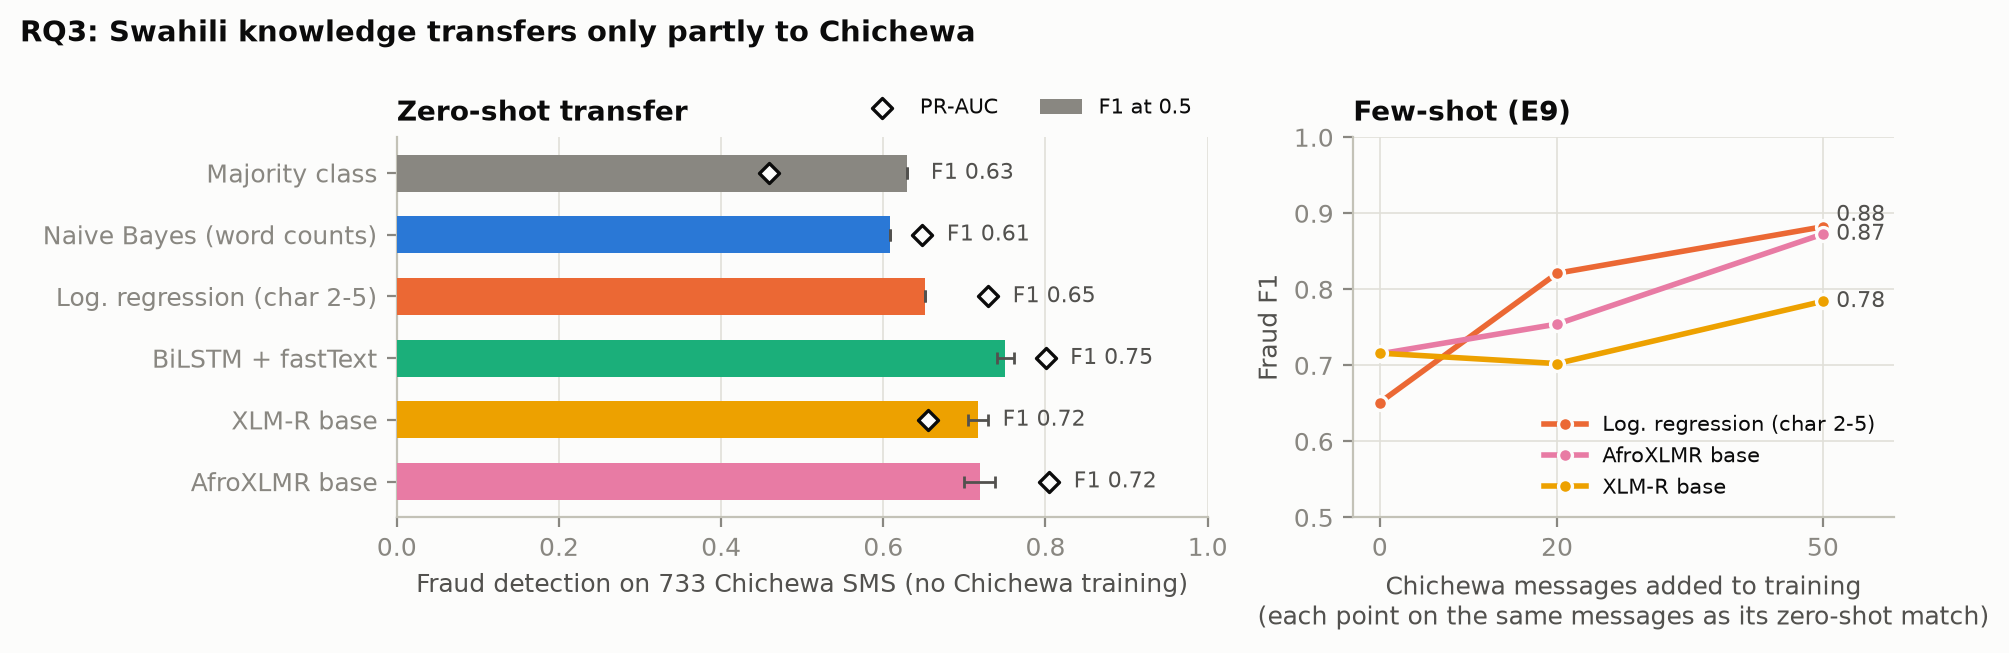

In [2]:
display(Image(str(config.FIGURES / 'rq3_transfer.png')))

In [3]:
models = ['majority', 'phone_rule', 'nb_word_counts', 'lr_char', 'bilstm_finetuned', 'xlmr', 'afroxlmr']
for metric in ['f1', 'pr_auc', 'precision', 'recall']:
    display(Markdown(f'**{metric}**'))
    display(table(models, ['chichewa/all', 'chichewa/dchi', 'chichewa/dedup'], metric=metric))

**f1**

set,chichewa/all,chichewa/dchi,chichewa/dedup
model,,,
majority,0.629,0.665,0.628
phone_rule,0.681,0.690,0.672
nb_word_counts,0.608,0.640,0.600
lr_char,0.651,0.668,0.642
bilstm_finetuned,0.750,0.768,0.758
xlmr,0.717,0.768,0.729
afroxlmr,0.719,0.763,0.721


**pr_auc**

set,chichewa/all,chichewa/dchi,chichewa/dedup
model,,,
majority,0.458,0.498,0.458
phone_rule,0.692,0.726,0.690
nb_word_counts,0.648,0.707,0.658
lr_char,0.730,0.800,0.738
bilstm_finetuned,0.800,0.843,0.801
xlmr,0.654,0.730,0.671
afroxlmr,0.805,0.855,0.809


**precision**

set,chichewa/all,chichewa/dchi,chichewa/dedup
model,,,
majority,0.458,0.498,0.458
phone_rule,0.878,0.908,0.888
nb_word_counts,0.501,0.545,0.494
lr_char,0.804,0.856,0.811
bilstm_finetuned,0.799,0.841,0.806
xlmr,0.586,0.657,0.601
afroxlmr,0.719,0.812,0.730


**recall**

set,chichewa/all,chichewa/dchi,chichewa/dedup
model,,,
majority,1.000,1.000,1.000
phone_rule,0.556,0.556,0.541
nb_word_counts,0.774,0.774,0.766
lr_char,0.548,0.548,0.531
bilstm_finetuned,0.707,0.707,0.714
xlmr,0.929,0.929,0.929
afroxlmr,0.723,0.723,0.718


## Few-shot (E9)

In [4]:
t = S[S.model.isin(['lr_char', 'afroxlmr', 'xlmr']) & S.variant.isin(['clean', 'fewshot20', 'fewshot50']) & (S.set == 'chichewa/all')]
t.pivot_table(index='model', columns='variant', values=['f1', 'pr_auc']).round(3)

f1                     pr_auc                    
variant   clean fewshot20 fewshot50  clean fewshot20 fewshot50
model                                                         
afroxlmr  0.719     0.754     0.873  0.805     0.872     0.939
lr_char   0.651     0.821     0.882  0.730     0.896     0.948
xlmr      0.717     0.702     0.784  0.654     0.749     0.857

## Where transfer fails: telco service texts

The Chichewa genuine class includes telco balance and bundle messages, which carry amounts and short codes, unlike any genuine BongoScam text.

In [5]:
chi = pd.read_csv(config.DATA_PROCESSED / 'chichewa.csv').set_index('id')
p = pd.read_csv(config.PREDICTIONS / 'afroxlmr__clean__template__s42.csv', keep_default_na=False)
p = p[p.set == 'chichewa'].assign(source=lambda d: d.id.map(chi.source), text=lambda d: d.id.map(chi.text))
p.assign(flagged=p.prob >= 0.5).groupby(['source', 'label']).flagged.mean().round(3)

source        label
D_CHI         0        0.133
              1        0.655
telcoSMS_CHI  0        0.441
Name: flagged, dtype: float64

**Reading.** Over 3 seeds AfroXLMR flags 67% +- 20% of genuine telco texts but 17% +- 4% of other genuine texts: amounts and short codes look like fraud to a model that never saw a genuine service message. Zero-shot, the 9-word length rule (F1 0.72) does as well as the transformers. AfroXLMR ranks Chichewa fraud better than XLM-R (PR-AUC +0.15, p < 0.001), but a BiLSTM over Swahili fastText vectors ranks as well (PR-AUC 0.80 vs 0.81). With 50 Chichewa examples AfroXLMR reaches F1 0.87 against XLM-R's 0.78 (p < 0.001), so among transformers the Africa-centric one (pretrained with Chichewa) adapts faster; but the char LR, with no pretraining at all, reaches 0.88 (difference n.s.).